In [1]:
from pathlib import Path
from scipy.ndimage import center_of_mass
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform as sk_transform

In [2]:
def custom_crop_resize(image, shape, resized_shape, length=90, cm_shift_x=10, cm_shift_y=-10):
    cm = center_of_mass(image)
    new_cm_x = int(cm[1]) + cm_shift_x
    new_cm_y = int(cm[0]) + cm_shift_y
    start_x = new_cm_x - length // 2
    start_y = new_cm_y - length // 2
    end_x = start_x + length
    end_y = start_y + length
    cropped_image = image[start_y:end_y, start_x:end_x]
    plt.imshow(image, cmap="gray")
    # plot the center of mass as a red dot
    plt.scatter(new_cm_x, new_cm_y, color="r")
    plt.scatter(start_x, start_y, color="g")
    plt.scatter(end_x, end_y, color="b")
    plt.axis("off")
    resized_image = sk_transform.resize(cropped_image, resized_shape)
    return resized_image

In [3]:
basepath = Path("/src/project/data/experiment")
exc_fname = basepath / "exc_images.npy"

In [4]:
images = np.load(exc_fname, allow_pickle=True)
images = np.array([np.array(x) for x in images]).astype(np.float64)

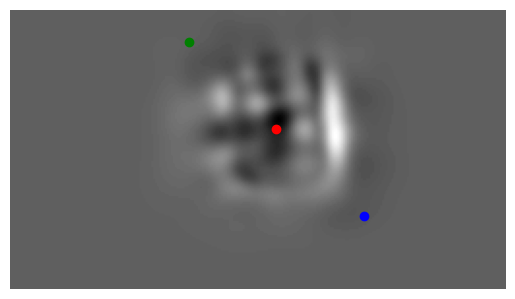

In [5]:
image_0 = custom_crop_resize(images[0], (90, 90), (36, 36))

(-0.5, 35.5, 35.5, -0.5)

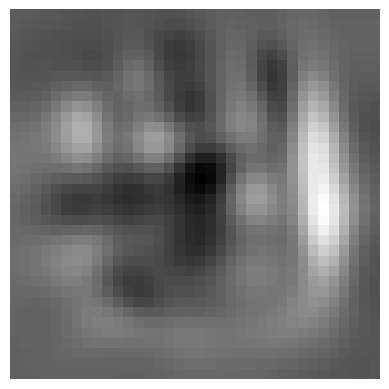

In [6]:
plt.imshow(image_0, cmap="gray")
plt.axis("off")

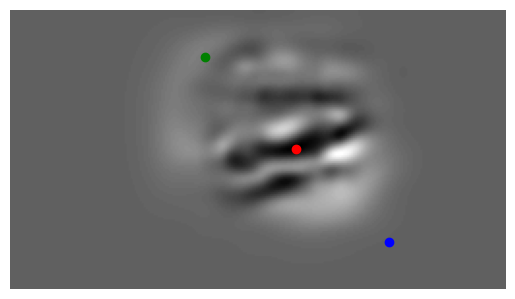

In [14]:
image_1 = custom_crop_resize(images[1], (90, 90), (36, 36), length=95, cm_shift_x=20, cm_shift_y=0)

(-0.5, 35.5, 35.5, -0.5)

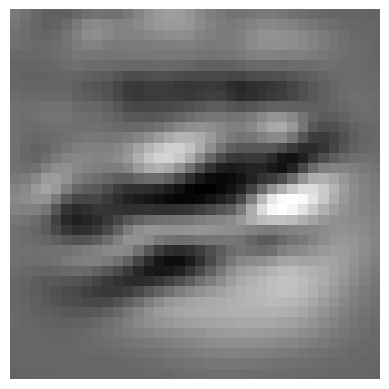

In [15]:
plt.imshow(image_1, cmap="gray")
plt.axis("off")

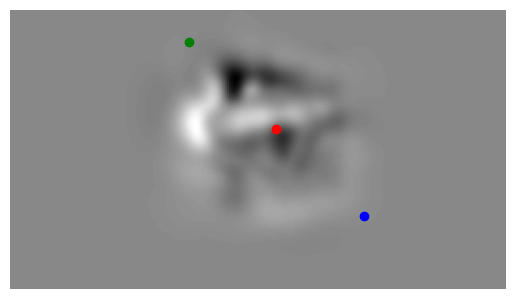

In [18]:
image_2 = custom_crop_resize(images[2], (90, 90), (36, 36), length=90)

(-0.5, 35.5, 35.5, -0.5)

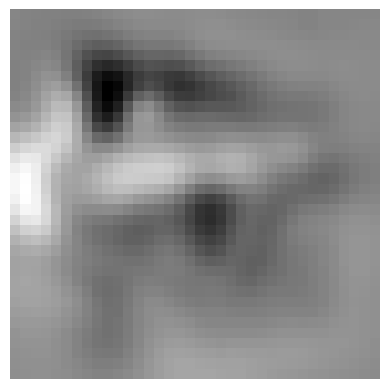

In [19]:
plt.imshow(image_2, cmap="gray")
plt.axis("off")

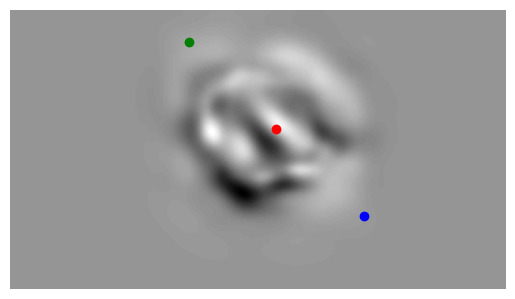

In [22]:
image_3 = custom_crop_resize(images[3], (90, 90), (36, 36), length=90)

(-0.5, 35.5, 35.5, -0.5)

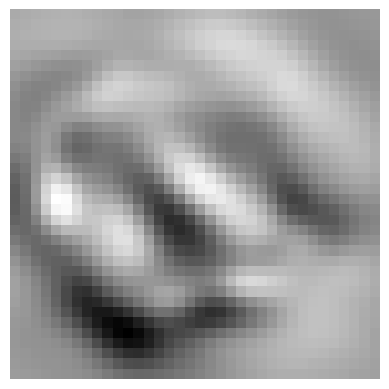

In [23]:
plt.imshow(image_3, cmap="gray")
plt.axis("off")

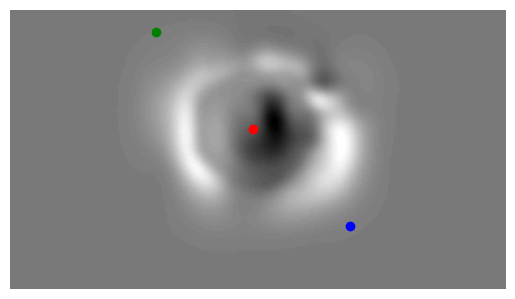

In [27]:
image_4 = custom_crop_resize(images[4], (90, 90), (36, 36), length=100, cm_shift_x=-2)

(-0.5, 35.5, 35.5, -0.5)

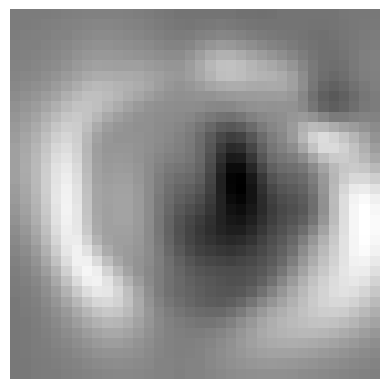

In [28]:
plt.imshow(image_4, cmap="gray")
plt.axis("off")

In [29]:
images = np.array([image_0, image_1, image_2, image_3, image_4])
custom_crop_path = basepath / "custom_centered_exc_crops.npy"
np.save(custom_crop_path, images)